# Importing Packages

In [1]:
from multiprocessing import Pool
import time
import random
import numpy as np
from sklearn.neighbors import NearestNeighbors
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from qiskit.circuit.library import RZGate, RYGate
from qiskit.quantum_info import random_unitary
import matplotlib as mpl
from matplotlib.ticker import FuncFormatter, NullFormatter, LogLocator
import matplotlib.ticker as mticker
from line_profiler import LineProfiler
import pickle
import importlib
import helpers
importlib.reload(helpers)
from helpers import rz_gate, tau_set, key_from_U, SequenceDB, generate_sequences, distance, db_to_nn, closest_neighbors

# Setting up

In [2]:
gate_to_id = {
    'X': 0,
    'Y': 1,
    'Z': 2,
    'H': 3,
    'S': 4,
    'Sdg': 5,
    'Rz(-1*π/4)': 6,
    'Rz(1*π/4)': 7,
    'EMS': 8,
    'I': 9,
    'EMS1': 10
}

id_to_gate = {
    0: 'X',
    1: 'Y',
    2: 'Z',
    3: 'H',
    4: 'S',
    5: 'Sdg',
    6: 'Rz(-1*π/4)',
    7: 'Rz(1*π/4)',
    8: 'EMS',
    9: 'I',
    10: 'EMS1'
}

In [3]:
# Creating the logical base gate set number 1
set1 = []

pauli_x = np.array([[0, 1], [1, 0]])
set1.append({"gate": pauli_x, "t_count": 0, "id": gate_to_id['X'], "magic_gate": False})

pauli_y = np.array([[0, -1j], [1j, 0]])
set1.append({"gate": pauli_y, "t_count": 0, "id": gate_to_id['Y'], "magic_gate": False})

pauli_z = np.array([[1, 0], [0, -1]])
set1.append({"gate": pauli_z, "t_count": 0, "id": gate_to_id['Z'], "magic_gate": False})

hadamard = 1/np.sqrt(2) * np.array([[1, 1], [1, -1]])
set1.append({"gate": hadamard, "t_count": 0, "id": gate_to_id['H'], "magic_gate": False})

s_gate = rz_gate(np.pi/2)
set1.append({"gate": s_gate, "t_count": 0, "id": gate_to_id['S'], "magic_gate": False})

sdg_gate = rz_gate(-np.pi/2)
set1.append({"gate": sdg_gate, "t_count": 0, "id": gate_to_id['Sdg'], "magic_gate": False})

set1 = set1 + tau_set(3)

In [4]:
# Adding 3Q exotic magic gate to set1 to create exotic_set1
theta = np.arctan(np.sqrt((np.sqrt(5) - 1) / 2))
ry_theta = np.array([[np.cos(theta/2), -np.sin(theta/2)], [np.sin(theta/2), np.cos(theta/2)]])
exotic_entry = {"gate": ry_theta, "t_count": 0, "id": gate_to_id['EMS'], "magic_gate": True}

exotic_set1 = set1.copy()
exotic_set1.append(exotic_entry)

In [5]:
# Adding 2Q exotic magic gate to set1 to create exotic_set2
x_star = 1/3 * (-2 + np.cbrt(19-3*np.sqrt(33)) + np.cbrt(19+3*np.sqrt(33)))
theta_star = np.arcsin(x_star)
ry_theta_star = np.array([[np.cos(theta_star/2), -np.sin(theta_star/2)], [np.sin(theta_star/2), np.cos(theta_star/2)]])
exotic_entry1 = {"gate": ry_theta_star, "t_count": 0, "id": gate_to_id['EMS1'], "magic_gate": True}

exotic_set2 = set1.copy()
exotic_set2.append(exotic_entry1)

In [6]:
# Adding both 2Q and 3Q exotic magic gate to set1 to create exotic_set3
exotic_set3 = set1.copy()
exotic_set3.append(exotic_entry)
exotic_set3.append(exotic_entry1)

# Running the Algorithm

In [ ]:
exotic_set1_max6 = generate_sequences(exotic_set1, 6)

In [ ]:
print(len(exotic_set1_max6))

336409


In [ ]:
exotic_set2_max6 = generate_sequences(exotic_set2, 6)

In [ ]:
exotic_set3_max6 = generate_sequences(exotic_set3, 6)

Saving or loading data

In [ ]:
# Saving
exotic_set1_max6.save("exotic_set1_max6.pkl")
exotic_set2_max6.save("exotic_set2_max6.pkl")
exotic_set3_max6.save("exotic_set3_max6.pkl")

In [ ]:
# Loading
exotic_set1_max6 = SequenceDB.load("exotic_set1_max6.pkl")

# Graphing Settings

In [7]:
mpl.rcParams.update({
    'text.usetex': True,
    'mathtext.fontset': 'cm',
    'font.family': 'serif',
    'font.size': 8,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'lines.linewidth': 1.2,
    'figure.dpi': 150,
})

# Graphing results

In [32]:
# Loading
exotic_set1_max6 = SequenceDB.load("exotic_set1_max6.pkl")

In [33]:
exotic_nn6 = db_to_nn(exotic_set1_max6)

In [ ]:
# Set the approximation-error values to test
epsilon_list = np.linspace(0.05, 0.1, 6)

# Number of random target unitaries per epsilon
num_random_unitaries = 500

# Store averaged results
y_axis = []  # average magic count
x_axis = []  # inverse average distance

for i, epsilon in enumerate(epsilon_list):
    # Accumulate totals for successful approximations
    temp_magic_count = 0
    temp_distance = 0
    hits = 0

    for _ in range(num_random_unitaries):
        # Generate a random single-qubit unitary
        random = np.array(random_unitary(2))

        # Find the best database approximation within epsilon
        best_magic, best_distance, best_unitary, best_seqs = closest_neighbors(
            random,
            exotic_set1_max6,
            exotic_nn6,
            epsilon,
            exotic_set1
        )

        # Only include successful searches
        if best_magic is not None and best_distance is not None:
            temp_magic_count += best_magic
            temp_distance += best_distance
            hits += 1

    # Average over successful hits
    y_axis.append(np.nan if hits == 0 else temp_magic_count / hits)
    x_axis.append(1 / (temp_distance / hits))

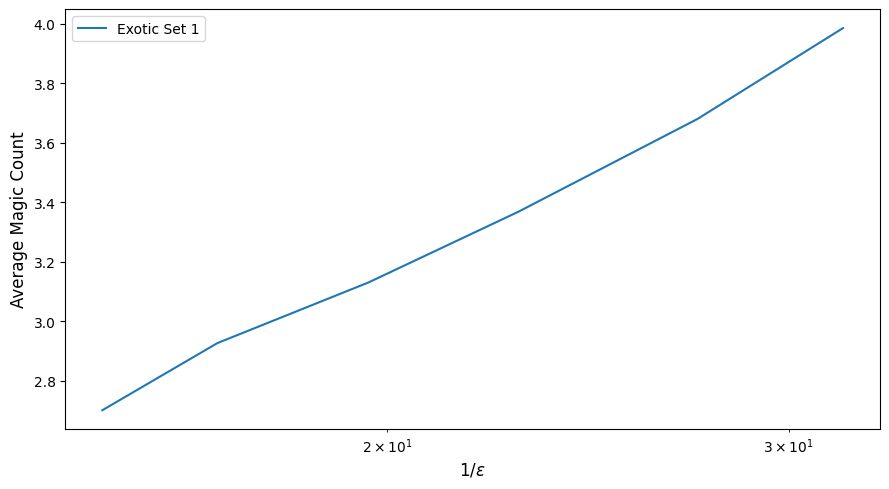

In [199]:
plt.figure(figsize=(9, 5))

plt.plot(x_axis, y_axis, label='Exotic Set 1')
#plt.plot(x_axis, [3.067*x - 4.322 for x in x_axis], label='Set 1')

plt.xlabel(r"$1/\epsilon$", fontsize=12)
plt.ylabel("Average Magic Count", fontsize=12)
#plt.yscale('log')
plt.xscale('log')
plt.tight_layout()
plt.legend()
plt.show()

# Graphing Cluster Results

In [8]:
data1 = np.load("xy_data_exotic_set1.npz")
data2 = np.load("xy_data_exotic_set2.npz")
data3 = np.load("xy_data_exotic_set3.npz")

epsilon_list1 = data1["epsilon_list"]
y_axis1 = data1["y_axis"]
x_axis1 = data1["x_axis"]

epsilon_list2 = data2["epsilon_list"]
y_axis2 = data2["y_axis"]
x_axis2 = data2["x_axis"]

epsilon_list3 = data3["epsilon_list"]
y_axis3 = data3["y_axis"]
x_axis3 = data3["x_axis"]

In [9]:
# define a model
def log_model(x, a, b):
    return a * np.log(x) + b

# fit the model
params1, covariance1 = curve_fit(log_model, x_axis1, y_axis1)
a1, b1 = params1
params2, covariance2 = curve_fit(log_model, x_axis2, y_axis2)
a2, b2 = params2
params3, covariance3 = curve_fit(log_model, x_axis3, y_axis3)
a3, b3 = params3

# smooth x-values for drawing the fitted curve
x_fit1 = np.linspace(np.asarray(x_axis1).min(), np.asarray(x_axis1).max(), 400)
y_fit1 = log_model(x_fit1, a1, b1)
x_fit2 = np.linspace(np.asarray(x_axis2).min(), np.asarray(x_axis2).max(), 400)
y_fit2 = log_model(x_fit2, a2, b2)
x_fit3 = np.linspace(np.asarray(x_axis3).min(), np.asarray(x_axis3).max(), 400)
y_fit3 = log_model(x_fit3, a3, b3)

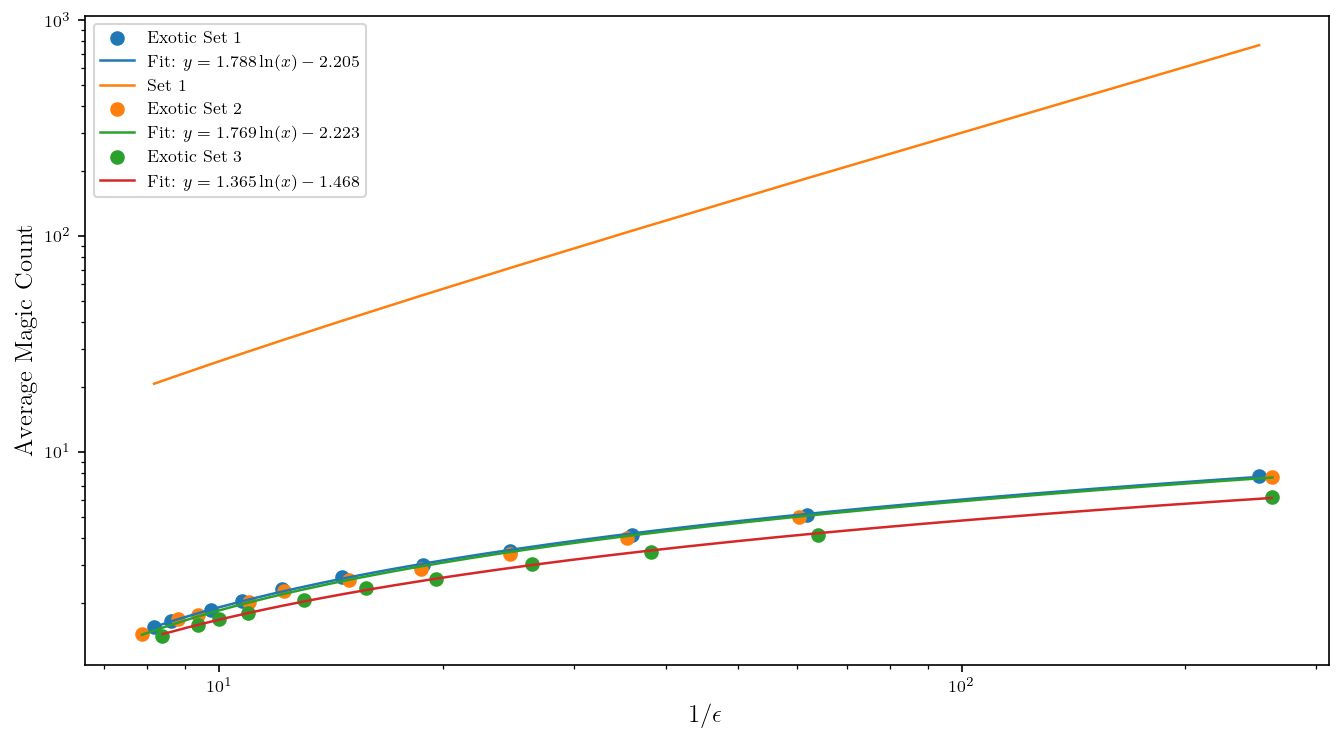

In [10]:
plt.figure(figsize=(9, 5))

plt.scatter(x_axis1, y_axis1, label='Exotic Set 1')
plt.plot(x_fit1, y_fit1, label=fr'Fit: $y={a1:.3f}\ln(x){b1:.3f}$')
plt.plot(x_axis1, [3.067*x - 4.322 for x in x_axis1], label='Set 1')
plt.scatter(x_axis2, y_axis2, label='Exotic Set 2')
plt.plot(x_fit2, y_fit2, label=fr'Fit: $y={a2:.3f}\ln(x){b2:.3f}$')
plt.scatter(x_axis3, y_axis3, label='Exotic Set 3')
plt.plot(x_fit3, y_fit3, label=fr'Fit: $y={a3:.3f}\ln(x){b3:.3f}$')

plt.xlabel(r"$1/\epsilon$", fontsize=12)
plt.ylabel("Average Magic Count", fontsize=12)
plt.yscale('log')
plt.xscale('log')
plt.tight_layout()
plt.legend()
plt.show()

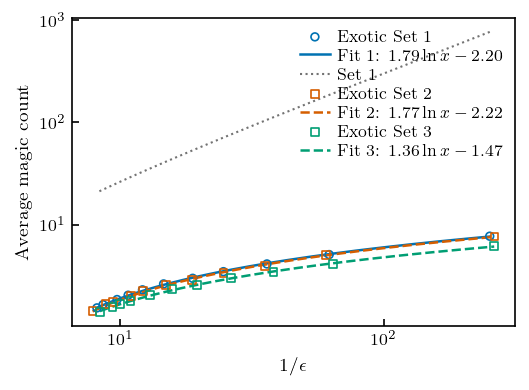

In [11]:
fig, ax = plt.subplots(figsize=(3.375, 2.45))

# Colorblind-friendly colors
c1 = "#0072B2"   # blue
c2 = "#D55E00"   # orange/red
c3 = "#009E73"   # green
gray = "0.45"

x_axis1 = np.asarray(x_axis1)
x_axis2 = np.asarray(x_axis2)
x_axis3 = np.asarray(x_axis3)

# Exotic Set 1
ax.scatter(
    x_axis1, y_axis1,
    s=14,
    marker='o',
    facecolors='none',
    edgecolors=c1,
    linewidths=0.8,
    label='Exotic Set 1',
    zorder=3
)

ax.plot(
    x_fit1, y_fit1,
    color=c1,
    linewidth=1.2,
    linestyle='-',
    label=fr'Fit 1: ${a1:.2f}\ln x {b1:+.2f}$',
    zorder=2
)

# Set 1 comparison line
set1_line = 3.067 * x_axis1 - 4.322
mask = set1_line > 0

ax.plot(
    x_axis1[mask],
    set1_line[mask],
    linewidth=1.0,
    linestyle=':',
    label=r'Set 1',
    color=gray,
    zorder=1
)

# Exotic Set 2
ax.scatter(
    x_axis2, y_axis2,
    s=14,
    marker='s',
    facecolors='none',
    edgecolors=c2,
    linewidths=0.8,
    label='Exotic Set 2',
    zorder=3
)

ax.plot(
    x_fit2, y_fit2,
    color=c2,
    linewidth=1.2,
    linestyle='--',
    label=fr'Fit 2: ${a2:.2f}\ln x {b2:+.2f}$',
    zorder=2
)

# Exotic Set 3
ax.scatter(
    x_axis3, y_axis3,
    s=14,
    marker='s',
    facecolors='none',
    edgecolors=c3,
    linewidths=0.8,
    label='Exotic Set 3',
    zorder=3
)

ax.plot(
    x_fit3, y_fit3,
    color=c3,
    linewidth=1.2,
    linestyle='--',
    label=fr'Fit 3: ${a3:.2f}\ln x {b3:+.2f}$',
    zorder=2
)

ax.set_xlabel(r"$1/\epsilon$")
ax.set_ylabel("Average magic count")

ax.set_xscale('log')
ax.set_yscale('log')

# Remove top and right ticks
ax.tick_params(which='both', direction='in', top=False, right=False)
ax.tick_params(which='major', length=3.5, width=0.8)
ax.tick_params(which='minor', length=2.0, width=0.6)

# Remove minor ticks if you want a cleaner log plot
ax.xaxis.set_minor_locator(mticker.NullLocator())
ax.xaxis.set_minor_formatter(mticker.NullFormatter())
ax.yaxis.set_minor_locator(mticker.NullLocator())
ax.yaxis.set_minor_formatter(mticker.NullFormatter())

ax.legend(
    frameon=False,
    loc='best',
    handlelength=1.8,
    handletextpad=0.45,
    borderpad=0.2,
    labelspacing=0.25,
    ncol=1
)

fig.tight_layout(pad=0.2)

plt.show()

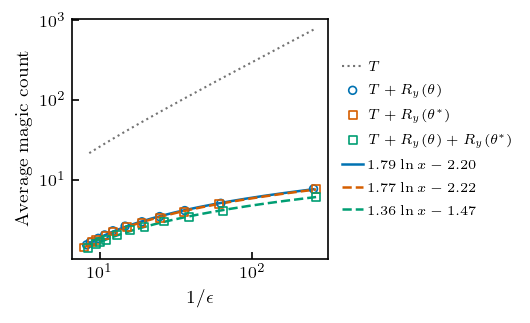

In [20]:
fig, ax = plt.subplots(figsize=(3.375, 2.0))

# Colorblind-friendly colors
c1 = "#0072B2"   # blue
c2 = "#D55E00"   # orange/red
c3 = "#009E73"   # green
gray = "0.45"

x_axis1 = np.asarray(x_axis1)
x_axis2 = np.asarray(x_axis2)
x_axis3 = np.asarray(x_axis3)

# Set 1 comparison line
set1_line = 3.067 * x_axis1 - 4.322
mask = set1_line > 0

ax.plot(
    x_axis1[mask],
    set1_line[mask],
    linewidth=1.0,
    linestyle=':',
    label=r'$T$',
    color=gray,
    zorder=1
)

# Exotic Set 1
ax.scatter(
    x_axis1, y_axis1,
    s=14,
    marker='o',
    facecolors='none',
    edgecolors=c1,
    linewidths=0.8,
    label=r'$T + R_y(\theta)$',
    zorder=3
)

# Exotic Set 2
ax.scatter(
    x_axis2, y_axis2,
    s=14,
    marker='s',
    facecolors='none',
    edgecolors=c2,
    linewidths=0.8,
    label=r'$T + R_y(\theta^*)$',
    zorder=3
)

# Exotic Set 3
ax.scatter(
    x_axis3, y_axis3,
    s=14,
    marker='s',
    facecolors='none',
    edgecolors=c3,
    linewidths=0.8,
    label=r'$T + R_y(\theta) + R_y(\theta^*)$',
    zorder=3
)

ax.plot(
    x_fit1, y_fit1,
    color=c1,
    linewidth=1.2,
    linestyle='-',
    label=fr'${a1:.2f}\ln x {b1:+.2f}$',
    zorder=2
)

ax.plot(
    x_fit2, y_fit2,
    color=c2,
    linewidth=1.2,
    linestyle='--',
    label=fr'${a2:.2f}\ln x {b2:+.2f}$',
    zorder=2
)


ax.plot(
    x_fit3, y_fit3,
    color=c3,
    linewidth=1.2,
    linestyle='--',
    label=fr'${a3:.2f}\ln x {b3:+.2f}$',
    zorder=2
)

ax.set_xlabel(r"$1/\epsilon$")
ax.set_ylabel("Average magic count")

ax.set_xscale('log')
ax.set_yscale('log')

# Remove top and right ticks
ax.tick_params(which='both', direction='in', top=False, right=False)
ax.tick_params(which='major', length=3.5, width=0.8)
ax.tick_params(which='minor', length=2.0, width=0.6)

# Remove minor ticks if you want a cleaner log plot
ax.xaxis.set_minor_locator(mticker.NullLocator())
ax.xaxis.set_minor_formatter(mticker.NullFormatter())
ax.yaxis.set_minor_locator(mticker.NullLocator())
ax.yaxis.set_minor_formatter(mticker.NullFormatter())

ax.legend(
    frameon=False,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    handlelength=1.5,
    handletextpad=0.35,
    borderpad=0.2,
    labelspacing=0.8,
    ncol=1,
    fontsize=6.5
)

fig.subplots_adjust(
    left=0.16,
    right=0.62,
    bottom=0.17,
    top=0.96
)

fig.tight_layout(pad=0.2)

plt.show()

# Estimating unitaries for QPE

In [ ]:
# Constant parameters
h1, h2, h3 = (0.79605, -0.18092, -0.32096)
alpha0, alpha1 = (-0.274220, -0.785398)
t = np.pi / (8*h1)

Approximating the two unitaries for state preparation

In [36]:
def find_approximation(nn, unitary):
    euclidean_dist, idxs = nn.kneighbors(np.array(key_from_U(unitary), dtype=float).reshape(1, -1), 1, return_distance=True)
    return euclidean_dist, idxs

In [37]:
state_prep_unitary1 = np.asarray(RYGate(alpha0).to_matrix(), dtype=complex)
state_prep_unitary2 = np.asarray(RZGate(alpha1).to_matrix(), dtype=complex)

print(state_prep_unitary1)
print(state_prep_unitary2)

[[ 0.99061514+0.j  0.13668081+0.j]
 [-0.13668081+0.j  0.99061514+0.j]]
[[0.92387956+0.38268336j 0.        +0.j        ]
 [0.        +0.j         0.92387956-0.38268336j]]


In [47]:
euclidean_dist, idxs = find_approximation(exotic_nn6, state_prep_unitary1)
idx = int(idxs[0, 0])
dist = float(euclidean_dist[0, 0])
print(idx, dist)
print(exotic_set1_max6.reconstruct_seq_names(idx, id_to_gate))

230512 0.05384310367459826
['H', 'Rz(-1*π/4)', 'H', 'EMS', 'Sdg', 'EMS', 'Y', 'EMS', 'Y', 'Rz(1*π/4)', 'H', 'EMS', 'Sdg']


In [48]:
euclidean_dist, idxs = find_approximation(exotic_nn6, state_prep_unitary2)
idx = int(idxs[0, 0])
dist = float(euclidean_dist[0, 0])
print(idx, dist)
print(exotic_set1_max6.reconstruct_seq_names(idx, id_to_gate))

7 8.16990246656122e-08
['Rz(-1*π/4)']


Approximating the single-qubit unitaries used in control-U

In [54]:
cu_unitary1 = np.asarray(RZGate(h1*t).to_matrix(), dtype=complex)
cu_unitary2 = np.asarray(RZGate(-h1*t).to_matrix(), dtype=complex)
cu_unitary3 = np.asarray(RZGate(h2*t).to_matrix(), dtype=complex)
cu_unitary4 = np.asarray(RZGate(-h2*t).to_matrix(), dtype=complex)

In [55]:
euclidean_dist, idxs = find_approximation(exotic_nn6, cu_unitary1)
idx = int(idxs[0, 0])
dist = float(euclidean_dist[0, 0])
print(idx, dist)
print(exotic_set1_max6.reconstruct_seq_names(idx, id_to_gate))

101956 0.033572040225247464
['H', 'Rz(-1*π/4)', 'H', 'Rz(1*π/4)', 'Y', 'EMS', 'Y', 'EMS', 'X', 'Rz(1*π/4)', 'H', 'EMS']


In [56]:
euclidean_dist, idxs = find_approximation(exotic_nn6, cu_unitary2)
idx = int(idxs[0, 0])
dist = float(euclidean_dist[0, 0])
print(idx, dist)
print(exotic_set1_max6.reconstruct_seq_names(idx, id_to_gate))

222966 0.033572040225247464
['H', 'Rz(-1*π/4)', 'H', 'Rz(-1*π/4)', 'H', 'EMS', 'Y', 'EMS', 'H', 'Rz(-1*π/4)', 'X', 'EMS', 'H']


In [57]:
euclidean_dist, idxs = find_approximation(exotic_nn6, cu_unitary3)
idx = int(idxs[0, 0])
dist = float(euclidean_dist[0, 0])
print(idx, dist)
print(exotic_set1_max6.reconstruct_seq_names(idx, id_to_gate))

96285 0.014954442570187788
['H', 'Rz(-1*π/4)', 'Y', 'Rz(1*π/4)', 'H', 'EMS', 'H', 'Rz(1*π/4)', 'X', 'Rz(-1*π/4)', 'H', 'Rz(-1*π/4)']


In [58]:
euclidean_dist, idxs = find_approximation(exotic_nn6, cu_unitary4)
idx = int(idxs[0, 0])
dist = float(euclidean_dist[0, 0])
print(idx, dist)
print(exotic_set1_max6.reconstruct_seq_names(idx, id_to_gate))

94577 0.014954442570187788
['H', 'Rz(-1*π/4)', 'X', 'Rz(1*π/4)', 'H', 'EMS', 'H', 'Rz(-1*π/4)', 'X', 'Rz(1*π/4)', 'H', 'Rz(1*π/4)']


Approximating the last unitary $R_z(\beta)$

In [ ]:
seed = time.time_ns()
rng = random.Random(seed)
beta = rng.uniform(0, np.pi / 2)

last_unitary = np.asarray(RZGate(beta).to_matrix(), dtype=complex)

In [66]:
euclidean_dist, idxs = find_approximation(exotic_nn6, last_unitary)
idx = int(idxs[0, 0])
dist = float(euclidean_dist[0, 0])
print(idx, dist)
print(exotic_set1_max6.reconstruct_seq_names(idx, id_to_gate))

223089 0.03327602660508147
['H', 'Rz(-1*π/4)', 'H', 'Rz(-1*π/4)', 'H', 'EMS', 'Y', 'EMS', 'Sdg', 'EMS', 'S', 'EMS', 'Sdg']
